In [1]:
import pandas as pd
df = pd.read_csv("../data/mig_cement_operations.csv")

In [2]:
site_id = 'SITE_001'
site_df = df[df['site_id'] == site_id].copy()

In [3]:
site_df.set_index('date', inplace=True)
site_df.index = pd.to_datetime(site_df.index)
site_df = site_df.sort_index()

In [4]:
y = site_df['consumed_tonnes']
exog = site_df[['planned_pour_tonnes', 'rain_mm', 'avg_temp_c', 'opening_inventory_tonnes',
	'deliveries_tonnes', 'silo_capacity']]

* check cases where consumed tonnes are zero.
* 

## Check for Seasonality: Weekly and Monthly

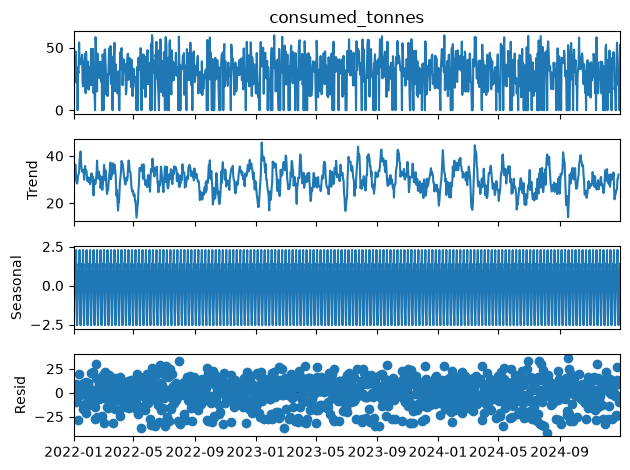

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(y, model='additive', period=7)
decomp.plot();

## Training the Base Model

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# split data
split_index = int(len(site_df) * 0.8)
X_train, X_test = exog.iloc[:split_index], exog.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [7]:
model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity = False
)

results = model.fit()
results.summary()

c:\Users\HomePC\Downloads\JULY 10Alytics DS Project\Novapay-fraudulent\nova-venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\HomePC\Downloads\JULY 10Alytics DS Project\Novapay-fraudulent\nova-venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\HomePC\Downloads\JULY 10Alytics DS Project\Novapay-fraudulent\nova-venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                   consumed_tonnes   No. Observations:                  876
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -3125.738
Date:                           Tue, 11 Aug 2026   AIC                           6273.476
Time:                                   16:13:57   BIC                           6325.878
Sample:                               01-01-2022   HQIC                          6293.531
                                    - 05-25-2024                                         
Covariance Type:                             opg                                         
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
planned_pour_tonnes          0.5455      0.020     26.872      0.000       0.506       0.585
rain_mm                     -0.8452      0.041    -20.838      0.000      -0.925      -0.766
avg_temp_c                   0.1166      0.038      3.068      0.002       0.042       0.191
opening_inventory_tonnes     0.2605      0.016     16.166      0.000       0.229       0.292
deliveries_tonnes            0.5665      0.029     19.229      0.000       0.509       0.624
silo_capacity               -0.0013   9119.989  -1.41e-07      1.000   -1.79e+04    1.79e+04
ar.L1                        0.1127      0.040      2.840      0.005       0.035       0.191
ma.L1                       -0.9996      0.035    -28.381      0.000      -1.069      -0.931
ar.S.L7                     -0.1813      0.650     -0.279      0.780      -1.456       1.093
ma.S.L7                      0.1996      0.649      0.308      0.758      -1.072       1.472
sigma2                      79.4633      4.710     16.870      0.000      70.231      88.695
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               128.68
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               1.22   Skew:                            -0.69
Prob(H) (two-sided):                  0.10   Kurtosis:                         4.28
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [8]:
y_pred = results.predict(start=y_test.index[0], end=y_test.index[-1], exog=X_test)

In [9]:
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error

def print_metrics(y_true, y_pred, label):
    mask = y_true != 0
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'{label} - MAPE: {mape:.2f}%, RMSE: {rmse:.2f} tonnes')

print_metrics(y_test, y_pred, 'SARIMAX')

SARIMAX - MAPE: 21.84%, RMSE: 9.01 tonnes


In [10]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=y_test.index,
    y=y_test,
    mode='lines',
    name='Actual',
    line=dict(color='black')
))

fig.add_trace(go.Scatter(
    x=y_test.index,
    y=y_pred,
    mode='lines',
    name='Forecast',
    line=dict(color='blue')
))

fig.update_layout(
    title=f'SARIMAX forecast Vs Actual - {site_df}',
    xaxis_title='Date',
    yaxis_title='Cement Consumed Tonnes',
    legend=dict(x=0, y=1),
    template='plotly_white',
    width=1000,
    height=450
)


fig.show()

- Still on training model, we want to see result on the entire dataset
- period: aggregrating on a monthly basis and to check for the result against weekly basis
- experiment with machine learning model e.g randomforest regressor
- can we use consumed tonnes to calculate for pour. if yes then there is a planned pour tonnees could be subject data leakage. 

## Data Leakage Check

In [11]:
# closing_inventory_tonnes is a same-day bookkeeping identity of the target, not a predictor
identity_diff = (site_df['opening_inventory_tonnes'] + site_df['deliveries_tonnes']
                  - site_df['consumed_tonnes'] - site_df['closing_inventory_tonnes']).abs()
print('closing = opening + deliveries - consumed, max abs diff:', identity_diff.max())

exog_cols=['planned_pour_tonnes', 'rain_mm', 'avg_temp_c', 'opening_inventory_tonnes',
	'deliveries_tonnes', 'silo_capacity']

closing = opening + deliveries - consumed, max abs diff: 2.842170943040401e-14


## Evaluate Across All Sites

Same SARIMAX pipeline as above (with `closing_inventory_tonnes` dropped), refit per site so we can see how MAPE varies beyond SITE_001.

In [12]:
site_mapes = []

for sid in sorted(df['site_id'].unique()):
    s = df[df['site_id'] == sid].copy()
    s['date'] = pd.to_datetime(s['date'])
    s = s.set_index('date').sort_index()

    y_s = s['consumed_tonnes']
    X_s = s[exog_cols]

    split = int(len(s) * 0.8)
    y_tr, y_te = y_s.iloc[:split], y_s.iloc[split:]
    X_tr, X_te = X_s.iloc[:split], X_s.iloc[split:]

    fit = SARIMAX(y_tr, exog=X_tr, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7),
                  enforce_stationarity=False).fit(disp=False)
    pred = fit.predict(start=y_te.index[0], end=y_te.index[-1], exog=X_te)

    mask = y_te != 0
    mape = mean_absolute_percentage_error(y_te[mask], pred[mask])
    site_mapes.append({'site_id': sid, 'mape': mape})

site_mapes = pd.DataFrame(site_mapes)
site_mapes.describe()

c:\Users\HomePC\Downloads\JULY 10Alytics DS Project\Novapay-fraudulent\nova-venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\HomePC\Downloads\JULY 10Alytics DS Project\Novapay-fraudulent\nova-venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\HomePC\Downloads\JULY 10Alytics DS Project\Novapay-fraudulent\nova-venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HomePC\Downloads\JULY 10Alytics DS Project\Novapay-fraudulent\nova-venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inf

,mape
count,30.000000
mean,0.189693
std,0.124132
min,0.063429
25%,0.071780
50%,0.198234
75%,0.238456
max,0.687263


In [13]:
site_mapes

,site_id,mape
0,SITE_001,0.218357
1,SITE_002,0.064722
2,SITE_003,0.269429
3,SITE_004,0.065769
4,SITE_005,0.176831
5,SITE_006,0.225787
6,SITE_007,0.196295
7,SITE_008,0.221140
8,SITE_009,0.075571
9,SITE_010,0.255497


In [14]:
fig = go.Figure(go.Bar(x=site_mapes['site_id'], y=site_mapes['mape']))
fig.update_layout(title='SARIMAX MAPE by Site', xaxis_title='Site', yaxis_title='MAPE',
                   template='plotly_white', width=1000, height=400)
fig.show()

## Weekly vs Monthly Aggregation

Resample SITE_001 to weekly and monthly frequency and compare MAPE against the daily baseline (using the corrected `exog_cols`, no seasonal term since weekly/monthly series are short).

In [15]:
agg_rules = {
    'consumed_tonnes': 'sum',
    'planned_pour_tonnes': 'sum',
    'deliveries_tonnes': 'sum',
    'opening_inventory_tonnes': 'first',
    'rain_mm': 'sum',
    'avg_temp_c': 'mean',
    'silo_capacity': 'last',
}

def evaluate_period(period_df, label):
    y_p = period_df['consumed_tonnes']
    X_p = period_df[exog_cols]

    split = int(len(period_df) * 0.8)
    y_tr, y_te = y_p.iloc[:split], y_p.iloc[split:]
    X_tr, X_te = X_p.iloc[:split], X_p.iloc[split:]

    fit = SARIMAX(y_tr, exog=X_tr, order=(1, 1, 1), enforce_stationarity=False).fit(disp=False)
    pred = fit.predict(start=y_te.index[0], end=y_te.index[-1], exog=X_te)

    mask = y_te != 0
    mape = mean_absolute_percentage_error(y_te[mask], pred[mask])
    print(f'{label}: n_obs={len(period_df)}, MAPE={mape:.3f}')
    return mape

daily_df = site_df.resample('D').agg(agg_rules)
weekly_df = site_df.resample('W').agg(agg_rules)
monthly_df = site_df.resample('ME').agg(agg_rules)

print(evaluate_period(daily_df, 'Daily'))
print(evaluate_period(weekly_df, 'Weekly'))
print(evaluate_period(monthly_df, 'Monthly'))

c:\Users\HomePC\Downloads\JULY 10Alytics DS Project\Novapay-fraudulent\nova-venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HomePC\Downloads\JULY 10Alytics DS Project\Novapay-fraudulent\nova-venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Daily: n_obs=1096, MAPE=0.219
0.21865038694017777


c:\Users\HomePC\Downloads\JULY 10Alytics DS Project\Novapay-fraudulent\nova-venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HomePC\Downloads\JULY 10Alytics DS Project\Novapay-fraudulent\nova-venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Weekly: n_obs=158, MAPE=0.098
0.09820521003298338
Monthly: n_obs=36, MAPE=0.024
0.024024132382453725


c:\Users\HomePC\Downloads\JULY 10Alytics DS Project\Novapay-fraudulent\nova-venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Random Forest Experiment

Same features (`exog_cols`) and same 80/20 split on SITE_001 daily data, swapping SARIMAX for a RandomForestRegressor to compare MAPE.

In [16]:
from sklearn.ensemble import RandomForestRegressor

X_train_rf, X_test_rf = site_df[exog_cols].iloc[:split_index], site_df[exog_cols].iloc[split_index:]
y_train_rf, y_test_rf = y.iloc[:split_index], y.iloc[split_index:]

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train_rf, y_train_rf)
y_pred_rf = rf.predict(X_test_rf)

mask_rf = y_test_rf != 0 #
mape_rf = mean_absolute_percentage_error(y_test_rf[mask_rf], y_pred_rf[mask_rf])
print(f'Random Forest MAPE: {mape_rf:.3f}')

pd.Series(rf.feature_importances_, index=exog_cols).sort_values(ascending=False)


Random Forest MAPE: 0.037


planned_pour_tonnes         0.306718
deliveries_tonnes           0.247584
rain_mm                     0.234211
opening_inventory_tonnes    0.194040
avg_temp_c                  0.017447
silo_capacity               0.000000
dtype: float64

### Compare RandomForest Regressor and SARIMAX on the entire dataset

In [17]:
train_frames, test_frames = [], []

for sid in sorted(df['site_id'].unique()):
    s = df[df['site_id'] == sid].copy()
    s['date'] = pd.to_datetime(s['date'])
    s = s.set_index('date').sort_index()
    s_weekly = s.resample('W').agg(agg_rules)

    split = int(len(s_weekly) * 0.8)
    train_frames.append(s_weekly.iloc[:split])
    test_frames.append(s_weekly.iloc[split:])

train_panel = pd.concat(train_frames)
test_panel = pd.concat(test_frames)

X_train_all, X_test_all = train_panel[exog_cols], test_panel[exog_cols]
y_train_all, y_test_all = train_panel['consumed_tonnes'], test_panel['consumed_tonnes']

print(f'Train rows: {len(train_panel)}, Test rows: {len(test_panel)}')

Train rows: 3780, Test rows: 960


In [18]:
rf_all = RandomForestRegressor(n_estimators=300, random_state=42)
rf_all.fit(X_train_all, y_train_all)
y_pred_rf_all = rf_all.predict(X_test_all)

mask = y_test_all != 0
mape_rf_all = mean_absolute_percentage_error(y_test_all[mask], y_pred_rf_all[mask]) * 100
print(f'Random Forest (entire dataset, weekly) MAPE: {mape_rf_all:.2f}%')

Random Forest (entire dataset, weekly) MAPE: 6.15%


In [19]:
# SARIMAX needs one continuous ordered index; the panel has duplicate weekly timestamps across sites, so refit on a plain RangeIndex (no seasonal term - weekly seasonality doesn't carry meaning across site boundaries in the stacked panel).
y_train_sarimax = y_train_all.reset_index(drop=True)
X_train_sarimax = X_train_all.reset_index(drop=True)
y_test_sarimax = y_test_all.reset_index(drop=True)
X_test_sarimax = X_test_all.reset_index(drop=True)
y_test_sarimax.index = range(len(y_train_sarimax), len(y_train_sarimax) + len(y_test_sarimax))
X_test_sarimax.index = y_test_sarimax.index

sarimax_all = SARIMAX(
    y_train_sarimax,
    exog=X_train_sarimax,
    order=(1, 1, 1),
    enforce_stationarity=False
).fit(disp=False)

y_pred_sarimax_all = sarimax_all.predict(
    start=y_test_sarimax.index[0], end=y_test_sarimax.index[-1], exog=X_test_sarimax
)

mask = y_test_sarimax != 0
mape_sarimax_all = mean_absolute_percentage_error(y_test_sarimax[mask], y_pred_sarimax_all[mask]) * 100
print(f'SARIMAX (entire dataset, weekly) MAPE: {mape_sarimax_all:.2f}%')

c:\Users\HomePC\Downloads\JULY 10Alytics DS Project\Novapay-fraudulent\nova-venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX (entire dataset, weekly) MAPE: 18.73%


In [20]:
print(f'SARIMAX MAPE:       {mape_sarimax_all:.2f}%')
print(f'Random Forest MAPE: {mape_rf_all:.2f}%')

fig = go.Figure(go.Bar(
    x=['SARIMAX', 'Random Forest'],
    y=[mape_sarimax_all, mape_rf_all],
))
fig.update_layout(
    title='SARIMAX vs Random Forest MAPE - Entire Dataset (weekly)',
    yaxis_title='MAPE (%)',
    template='plotly_white',
    width=500,
    height=400
)
fig.show()

SARIMAX MAPE:       18.73%
Random Forest MAPE: 6.15%
